In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/harshrishi7/feature/featured_master_dataset.csv')

In [4]:
df.head()

,timestamp,station_id,occupancy,duration,volume,price,datetime,num,count,fast_count,...,low_utilization,fast_charger_ratio,charger_category,CBD_area,available_time,charger_utilization_rate,revenue_per_session,energy_cost_per_kwh,queue_length_proxy,occupancy_density
0,1,102,12,0.49,2.858333,0.924,2022-06-19 00:00:00,1,30,3,...,0,0.1,Slow Dominant,Non-CBD,150,0.003267,0.203162,0.684518,0.196,7.017544
1,2,102,12,0.75,4.375000,0.924,2022-06-19 00:05:00,1,30,3,...,0,0.1,Slow Dominant,Non-CBD,150,0.005000,0.310962,0.752093,0.300,7.017544
2,3,102,12,0.75,4.375000,0.924,2022-06-19 00:10:00,1,30,3,...,0,0.1,Slow Dominant,Non-CBD,150,0.005000,0.310962,0.752093,0.300,7.017544
3,4,102,12,0.75,4.375000,0.924,2022-06-19 00:15:00,1,30,3,...,0,0.1,Slow Dominant,Non-CBD,150,0.005000,0.310962,0.752093,0.300,7.017544
4,5,102,12,0.75,4.375000,0.924,2022-06-19 00:20:00,1,30,3,...,0,0.1,Slow Dominant,Non-CBD,150,0.005000,0.310962,0.752093,0.300,7.017544


**INTRADAY OCCUPANCY CYCLES**


In [5]:
hourly_occ = (
    df.groupby('hour')['occupancy']
    .mean()
)

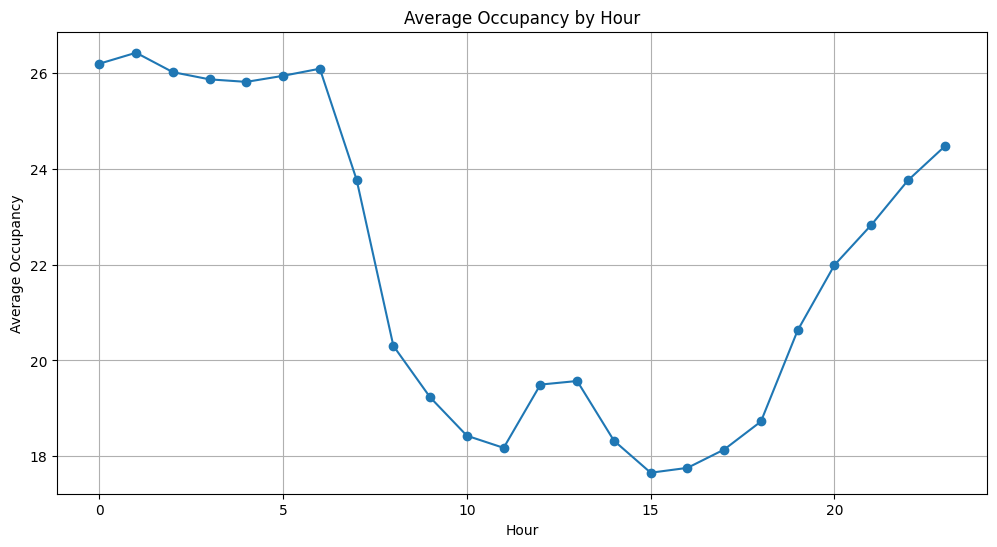

In [6]:
plt.figure(figsize=(12,6))

plt.plot(
    hourly_occ.index,
    hourly_occ.values,
    marker='o'
)

plt.title('Average Occupancy by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Occupancy')

plt.grid(True)

plt.show()

Charging station occupancy demonstrates a clear intraday cycle.
Occupancy is highest during late-night/early-morning and evening periods,
while mid-day hours show significantly lower utilization.
This suggests strong temporal clustering of charging demand.

**HOURLY VOLUME ANALYSIS**

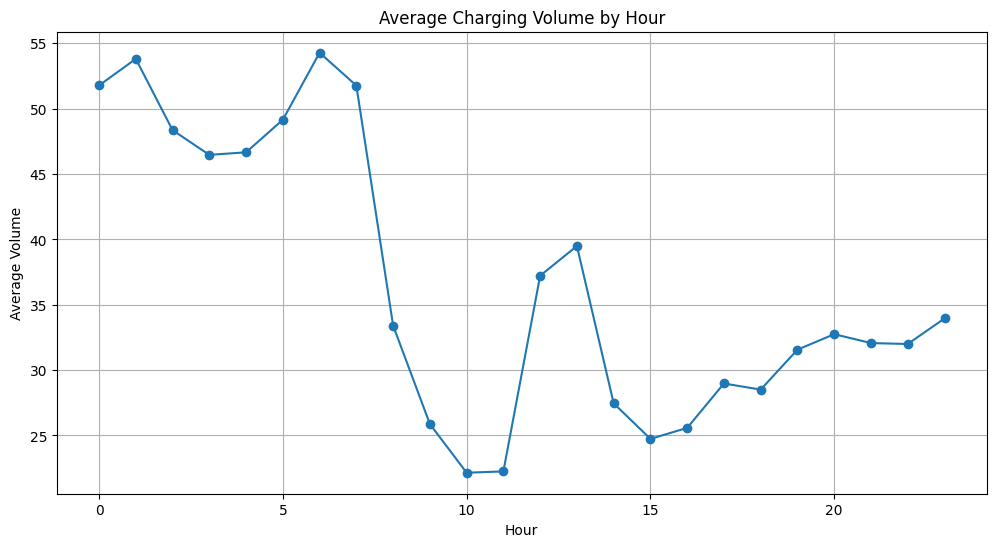

In [8]:
hourly_volume = (
    df.groupby('hour')['volume']
    .mean()
)
plt.figure(figsize=(12,6))

plt.plot(
    hourly_volume.index,
    hourly_volume.values,
    marker='o'
)

plt.title('Average Charging Volume by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Volume')

plt.grid(True)

plt.show()

Charging demand volume strongly correlates with occupancy behavior,
indicating that station congestion is directly linked to elevated charging demand periods.

**WEEKDAY VS WEEKEND ANALYSIS**

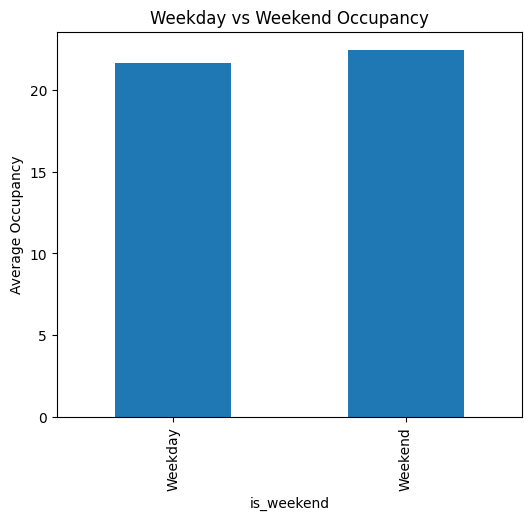

In [9]:
weekend_occ = (
    df.groupby('is_weekend')['occupancy']
    .mean()
)
plt.figure(figsize=(6,5))

weekend_occ.plot(kind='bar')

plt.xticks([0,1],['Weekday','Weekend'])

plt.title('Weekday vs Weekend Occupancy')
plt.ylabel('Average Occupancy')

plt.show()

Charging demand remains relatively stable across weekdays and weekends,
suggesting a balanced mix of residential, commercial, and continuous charging behavior.

**WEEKDAY DISTRIBUTION**

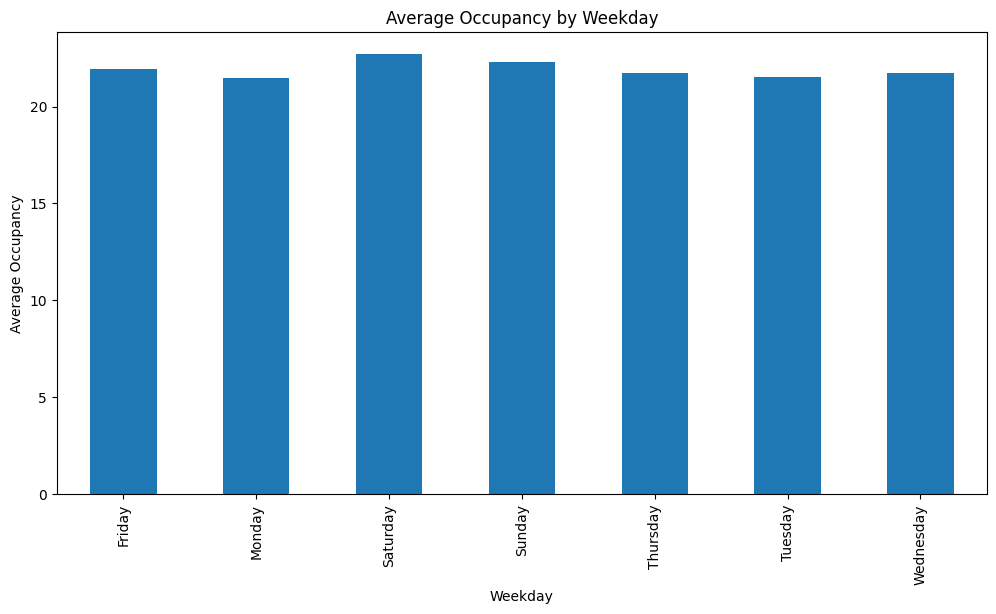

In [10]:
weekday_occ = (
    df.groupby('weekday')['occupancy']
    .mean()
)
plt.figure(figsize=(12,6))

weekday_occ.plot(kind='bar')

plt.title('Average Occupancy by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Occupancy')

plt.show()

Charging demand exhibits limited weekday variability,
indicating consistent operational demand throughout the week.
This suggests that charging infrastructure experiences persistent baseline utilization.

**PEAK PERIOD ANALYSIS**

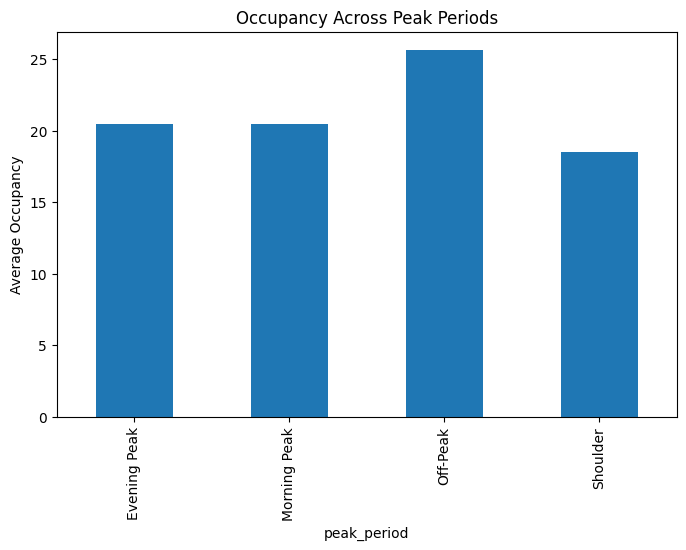

In [11]:
peak_analysis = (
    df.groupby('peak_period')['occupancy']
    .mean()
)
plt.figure(figsize=(8,5))

peak_analysis.plot(kind='bar')

plt.title('Occupancy Across Peak Periods')
plt.ylabel('Average Occupancy')

plt.show()

Off-peak periods demonstrate the highest occupancy levels,
suggesting significant overnight or long-duration charging behavior.
This indicates that users may already be naturally shifting toward lower-demand charging windows.

**REVENUE ANALYSIS**

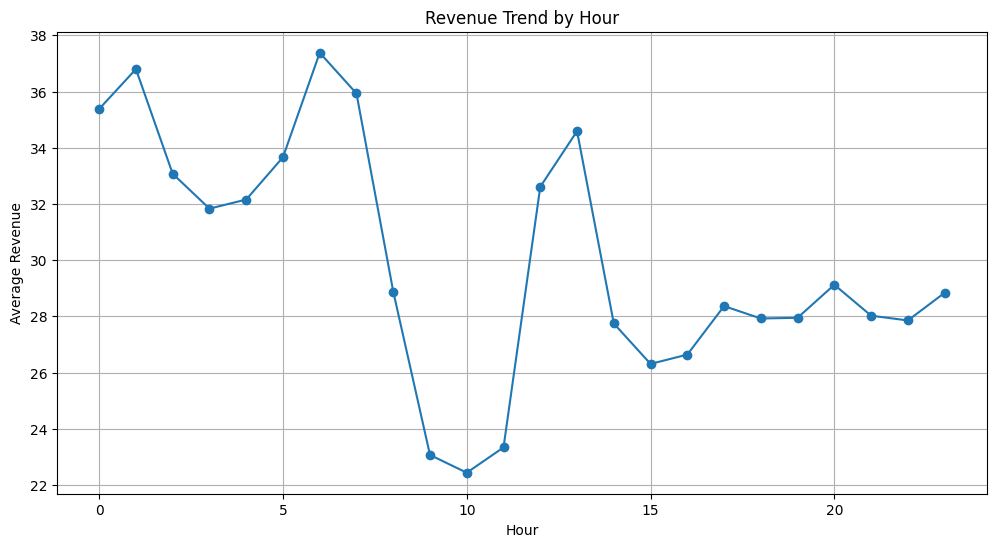

In [12]:
hourly_revenue = (
    df.groupby('hour')['revenue']
    .mean()
)
plt.figure(figsize=(12,6))

plt.plot(
    hourly_revenue.index,
    hourly_revenue.values,
    marker='o'
)

plt.title('Revenue Trend by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Revenue')

plt.grid(True)

plt.show()

Revenue generation is strongly concentrated during high-demand periods,
indicating that congestion and charging demand directly drive network profitability.

**CONGESTION ANALYSIS**

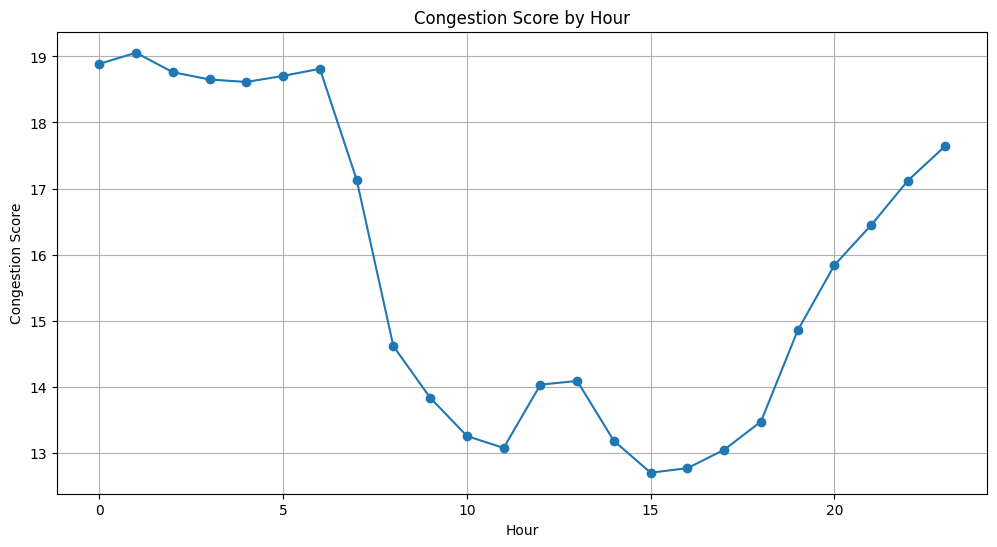

In [13]:
hourly_congestion = (
    df.groupby('hour')['congestion_score']
    .mean()
)
plt.figure(figsize=(12,6))

plt.plot(
    hourly_congestion.index,
    hourly_congestion.values,
    marker='o'
)

plt.title('Congestion Score by Hour')
plt.xlabel('Hour')
plt.ylabel('Congestion Score')

plt.grid(True)

plt.show()

Congestion intensity rises sharply during evening periods,
highlighting elevated charging pressure and increased likelihood of queue formation.

**QUEUE LENGTH ANALYSIS**

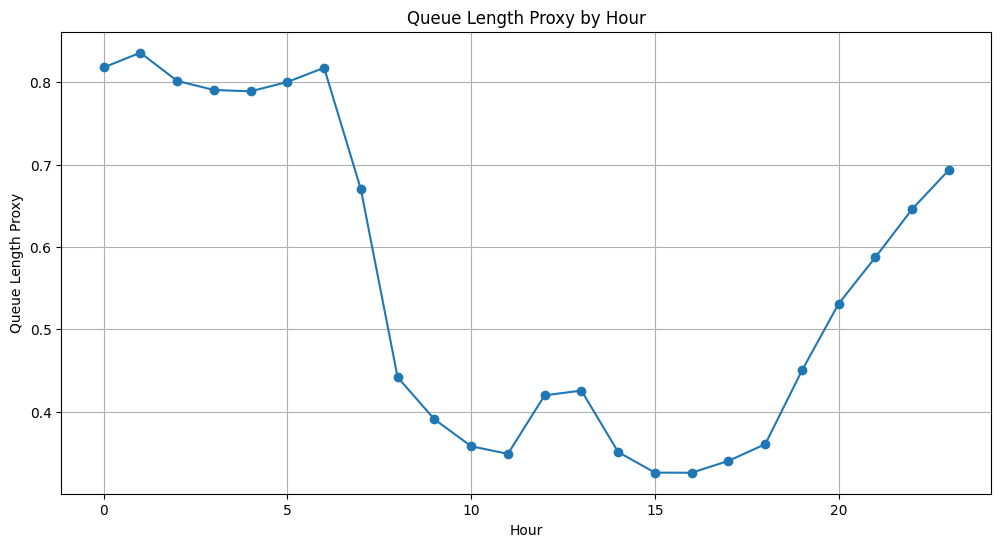

In [14]:
hourly_queue = (
    df.groupby('hour')['queue_length_proxy']
    .mean()
)
plt.figure(figsize=(12,6))

plt.plot(
    hourly_queue.index,
    hourly_queue.values,
    marker='o'
)

plt.title('Queue Length Proxy by Hour')
plt.xlabel('Hour')
plt.ylabel('Queue Length Proxy')

plt.grid(True)

plt.show()

Estimated queue pressure increases substantially during peak charging windows,
suggesting elevated waiting-time risks during high-demand periods.

**CHARGER CATEGORY ANALYSIS**

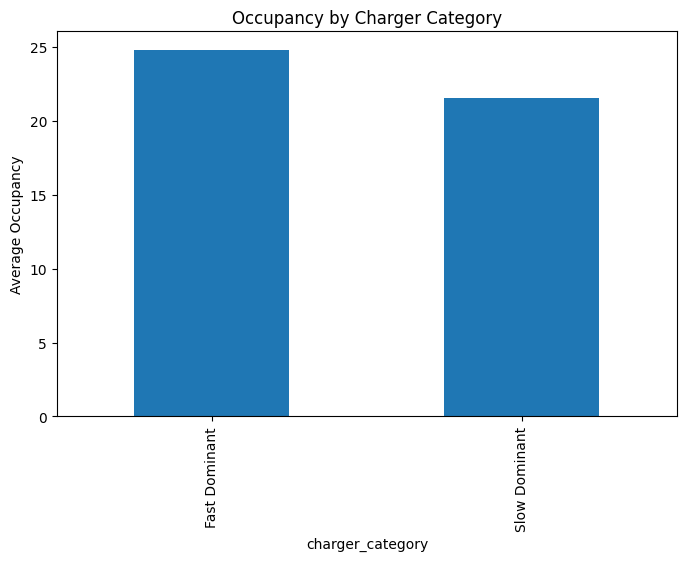

In [15]:
charger_occ = (
    df.groupby('charger_category')['occupancy']
    .mean()
)
plt.figure(figsize=(8,5))

charger_occ.plot(kind='bar')

plt.title('Occupancy by Charger Category')
plt.ylabel('Average Occupancy')

plt.show()

Fast-dominant stations exhibit higher occupancy,
suggesting commercial or fleet-oriented demand.

**UTILIZATION ANALYSIS**

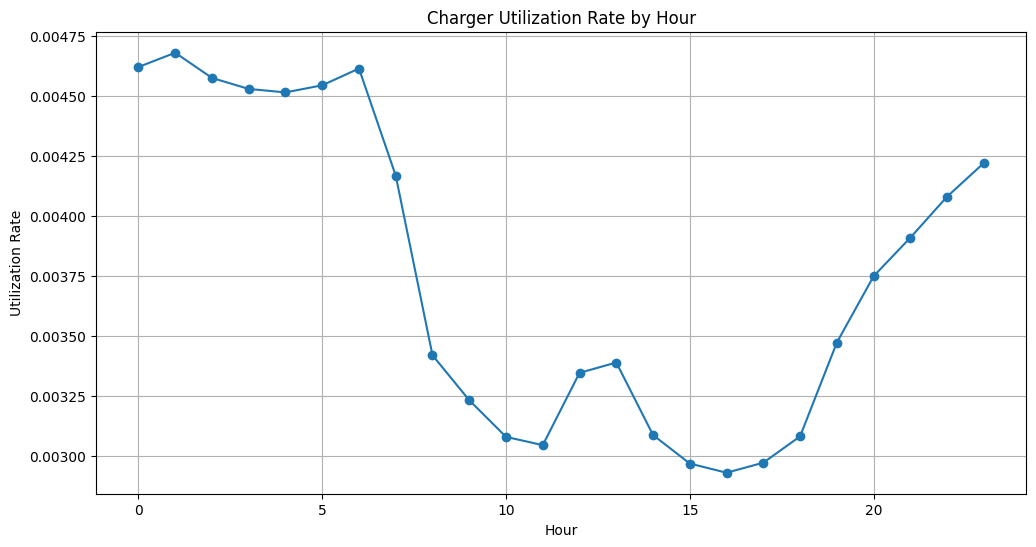

In [16]:
hourly_util = (
    df.groupby('hour')['charger_utilization_rate']
    .mean()
)
plt.figure(figsize=(12,6))

plt.plot(
    hourly_util.index,
    hourly_util.values,
    marker='o'
)

plt.title('Charger Utilization Rate by Hour')
plt.xlabel('Hour')
plt.ylabel('Utilization Rate')

plt.grid(True)

plt.show()

Infrastructure utilization demonstrates strong temporal variability,
with charging assets experiencing maximum stress during evening demand peaks.